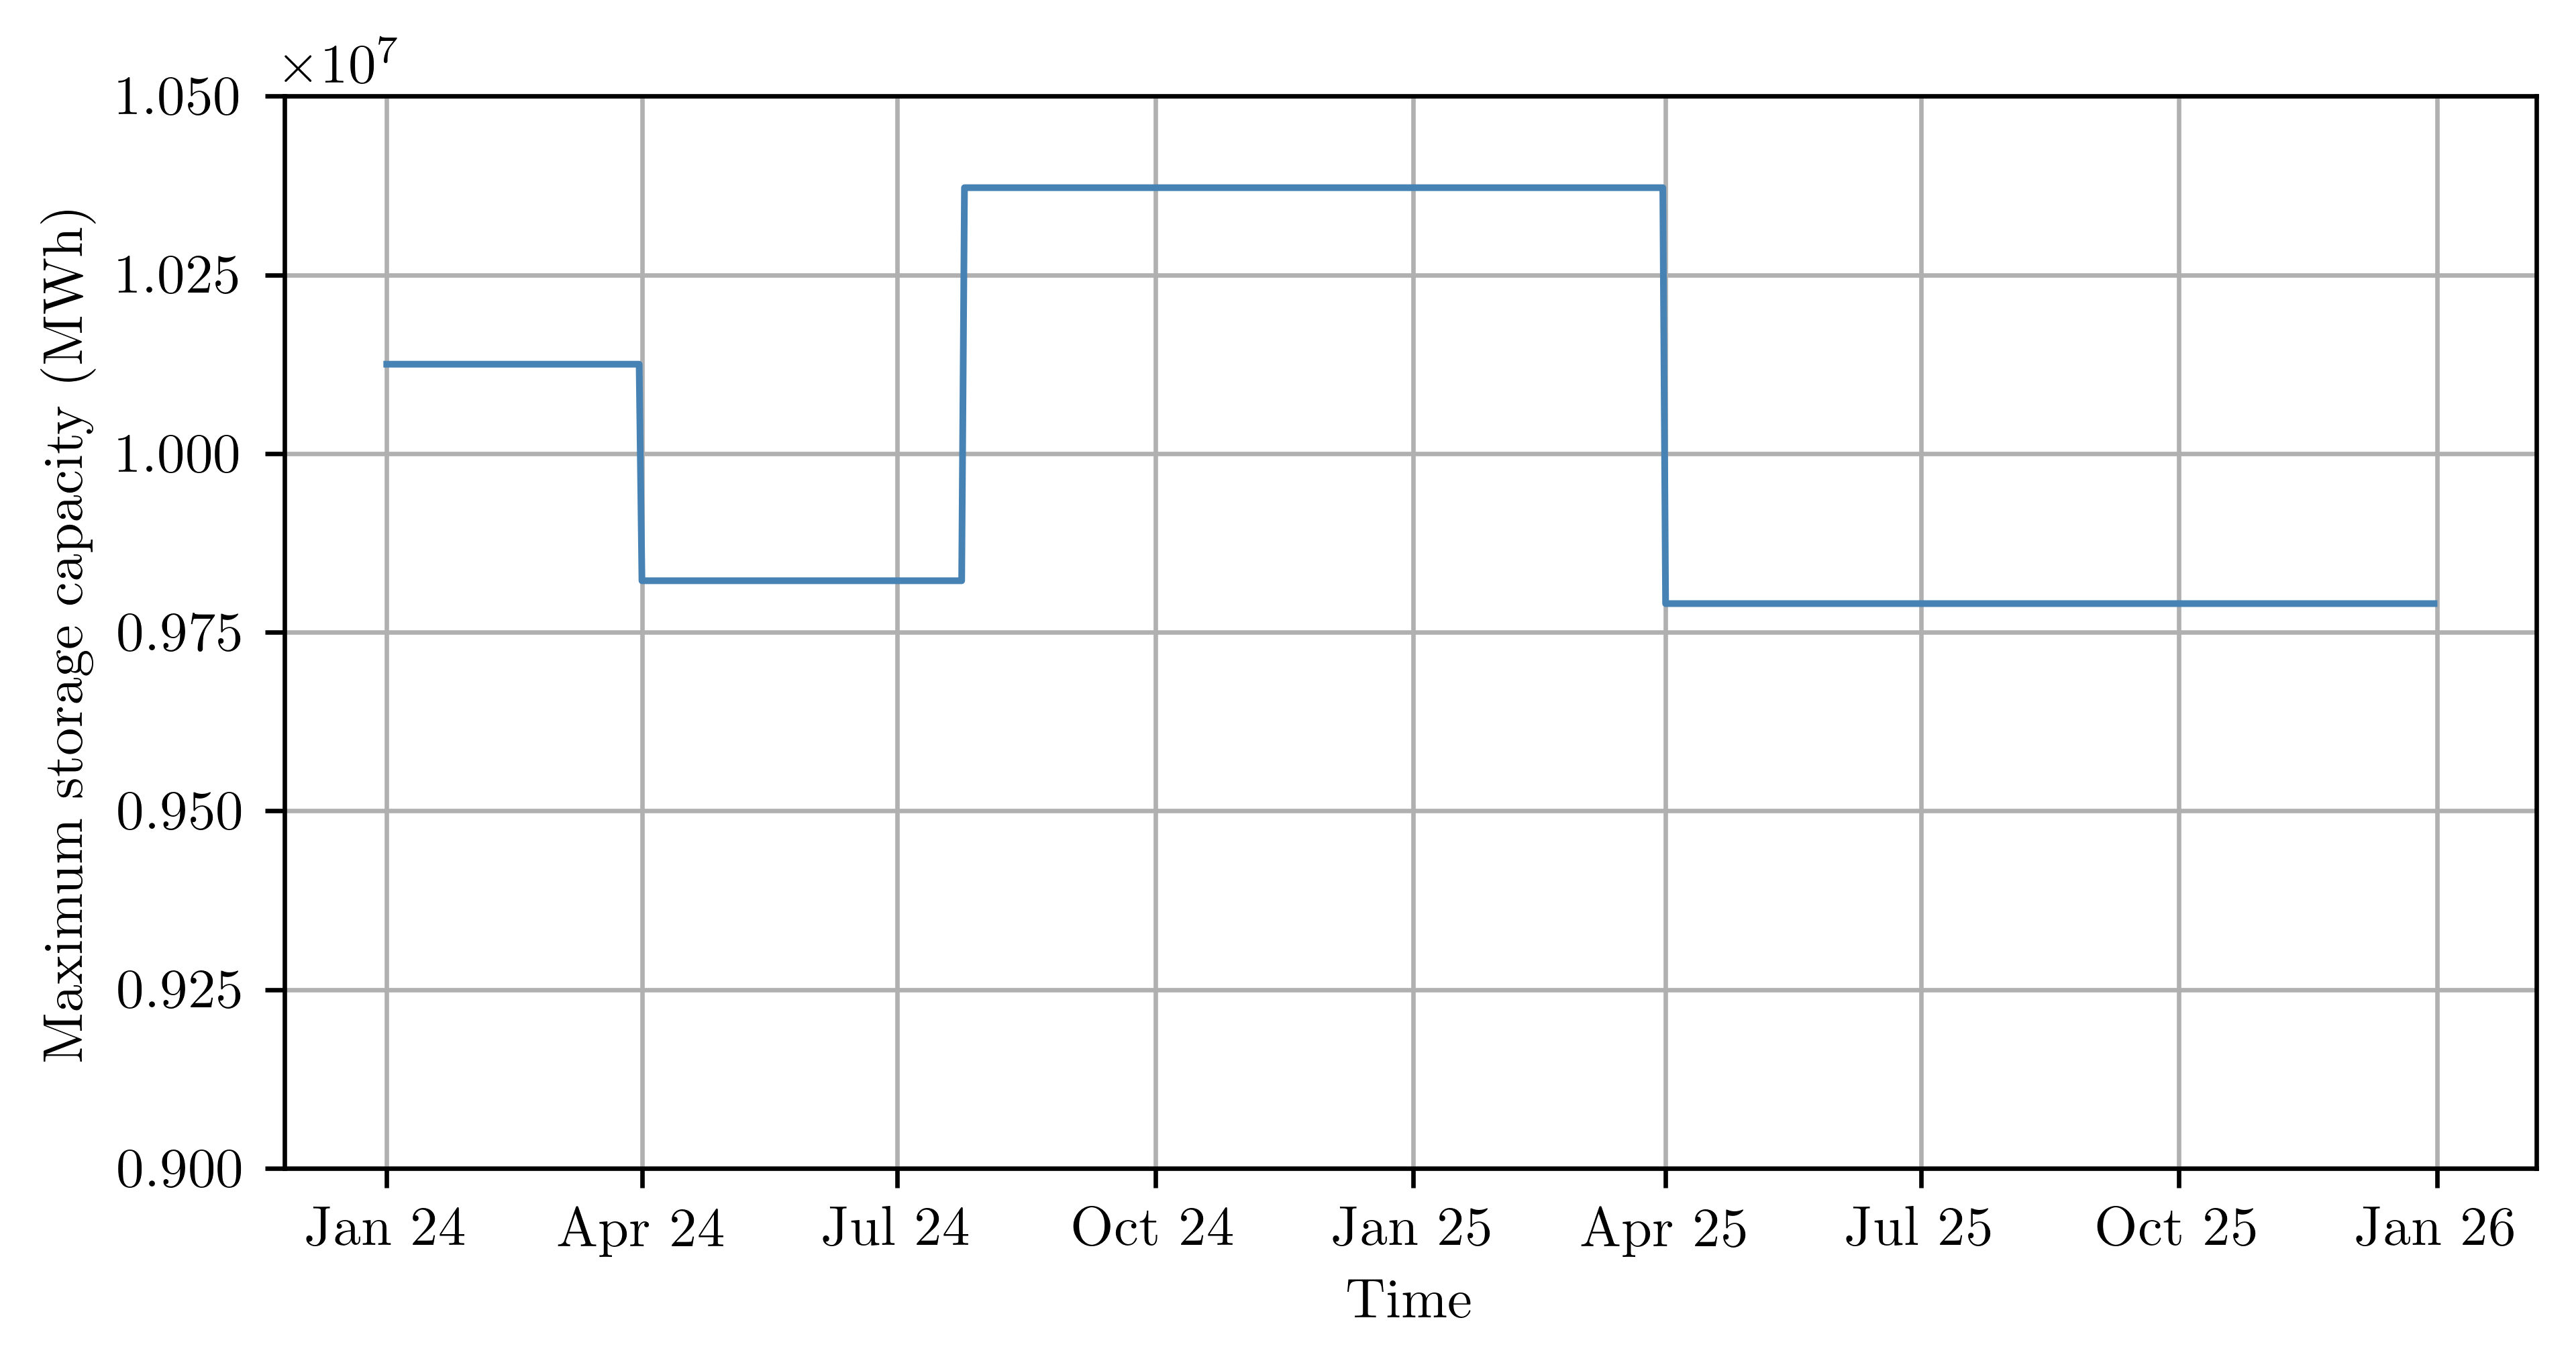

In [2]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib as mpl
import numpy as np
import pandas as pd

data = pd.read_excel("../data/storage_utilization_WG.xlsx")
data["Gas Day"] = pd.to_datetime(data["Gas Day"])
data = data[(data["Gas Day"] >= "2024-01-01") & (data["Gas Day"] <= "2025-12-31")]
data = data.sort_values("Gas Day")

# ---- Plot ----
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif":  ["Computer Modern Roman"],
})

fig, ax = plt.subplots(figsize=(6.5, 3.5), dpi=600)

# Inventory paths
ax.plot(data["Gas Day"], data["MAX STORAGE CAPACITY"], color="steelblue", lw=1.2,
        label="Maximum storage capacity")

ax.set_xlabel("Time")
ax.set_ylabel("Maximum storage capacity (MWh)")
ax.grid(True)

# Manually set tick positions and labels to avoid LaTeX/DateFormatter conflict.
# Generate one tick every 3 months across the date range.
tick_dates = pd.date_range(start=data["Gas Day"].min(), end=data["Gas Day"].max() + pd.DateOffset(months=1), freq="3MS")
ax.set_xticks([mdates.date2num(d) for d in tick_dates])
ax.set_xticklabels([d.strftime("%b %y") for d in tick_dates])

ax.set_yticks(np.arange(9000000, 10500001, 250000))
# ax.legend(loc="lower right", fontsize=8)
fig.tight_layout()
plt.savefig("../../fig/Plots/GSD_max_storage_capacity.png")
plt.show()